In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp

# Solve the generalized form of the free energy using Sympy

xhat = sp.Matrix([1,0,0])
yhat = sp.Matrix([0,1,0])
zhat = sp.Matrix([0,0,1])

phi = sp.symbols('phi')

phihat = -sp.sin(phi)*xhat + sp.cos(phi)*yhat

psi_0, psi = sp.symbols('psi_0 psi')

Id = sp.eye(3)

zeta, zeta_0 = sp.symbols('zeta zeta_0')

# Define the director field generalized
nhat_0 = -sp.sin(psi_0)*phihat + sp.cos(psi_0)*zhat

Lt_0 = Id + (zeta_0 - 1)*nhat_0*sp.transpose(nhat_0)

nhat = -sp.sin(psi)*phihat + sp.cos(psi)*zhat

Lt = Id + (zeta - 1)*nhat*sp.transpose(nhat)

Lets do a volume fixed elongation.

In [107]:
lam = sp.symbols('lambda')

Lambda = sp.diag(1/sp.sqrt(lam), 1/sp.sqrt(lam), lam)

mu = sp.symbols('mu')

f = mu/2 * (sp.trace(Lt_0 * sp.transpose(Lambda) * Lt.inv() * Lambda) + sp.log(Lt.det() / Lt_0.det()))

f = f.simplify()
f

mu*(-lambda**(3/2)*(zeta - 1)*(zeta_0 - 1)*sin(phi)**2*sin(psi)*sin(psi_0)*cos(psi)*cos(psi_0) - lambda**(3/2)*(zeta - 1)*(zeta_0 - 1)*sin(psi)*sin(psi_0)*cos(phi)**2*cos(psi)*cos(psi_0) + lambda**(3/2)*(lambda**(3/2)*((zeta_0 - 1)*cos(psi_0)**2 + 1)*(-zeta*cos(psi)**2 + zeta + cos(psi)**2) - (zeta - 1)*(zeta_0 - 1)*(cos(2*psi - 2*psi_0) - cos(2*psi + 2*psi_0))/8) + lambda*zeta*log(zeta/zeta_0) - 2*(zeta - 1)*(zeta_0 - 1)*sin(phi)**2*sin(psi)**2*sin(psi_0)**2*cos(phi)**2 + ((zeta_0 - 1)*sin(phi)**2*sin(psi_0)**2 + 1)*(-zeta*sin(phi)**2*sin(psi)**2 + zeta + sin(phi)**2*sin(psi)**2) + ((zeta_0 - 1)*sin(psi_0)**2*cos(phi)**2 + 1)*(zeta*sin(phi)**2*sin(psi)**2 - zeta*sin(psi)**2 + zeta - sin(phi)**2*sin(psi)**2 + sin(psi)**2))/(2*lambda*zeta)

In [108]:
f = f.trigsimp()

# Supposing a 0-twist angle
f_nem = f.evalf(subs={psi_0:0, psi:0})

df_dlam = sp.diff(f_nem, lam).simplify()

sol_lam = sp.solve(df_dlam, lam)

sol_lam[0]

(zeta/zeta_0)**(1/3)

So I get a relationship between the step-length scales and the deformation parameter under the constrain of a fixed volume, which in reality for hydration doesnt happen.

So, what Im modelling is a deformation which changes the step-length scales (for $\lambda \neq 1$), in the nematic limit, with the constrain that the deformation doesnt change the volume. Also, the system is homogeneous given that is nematic.

So what this tells me is that if $\zeta = \zeta_0$, that is that the anisotropy didnt change, therefore there was not a deformation at all: $\lambda = 1$. So this step-length scales are more related with the arrengement that takes the LCE after the deformation!

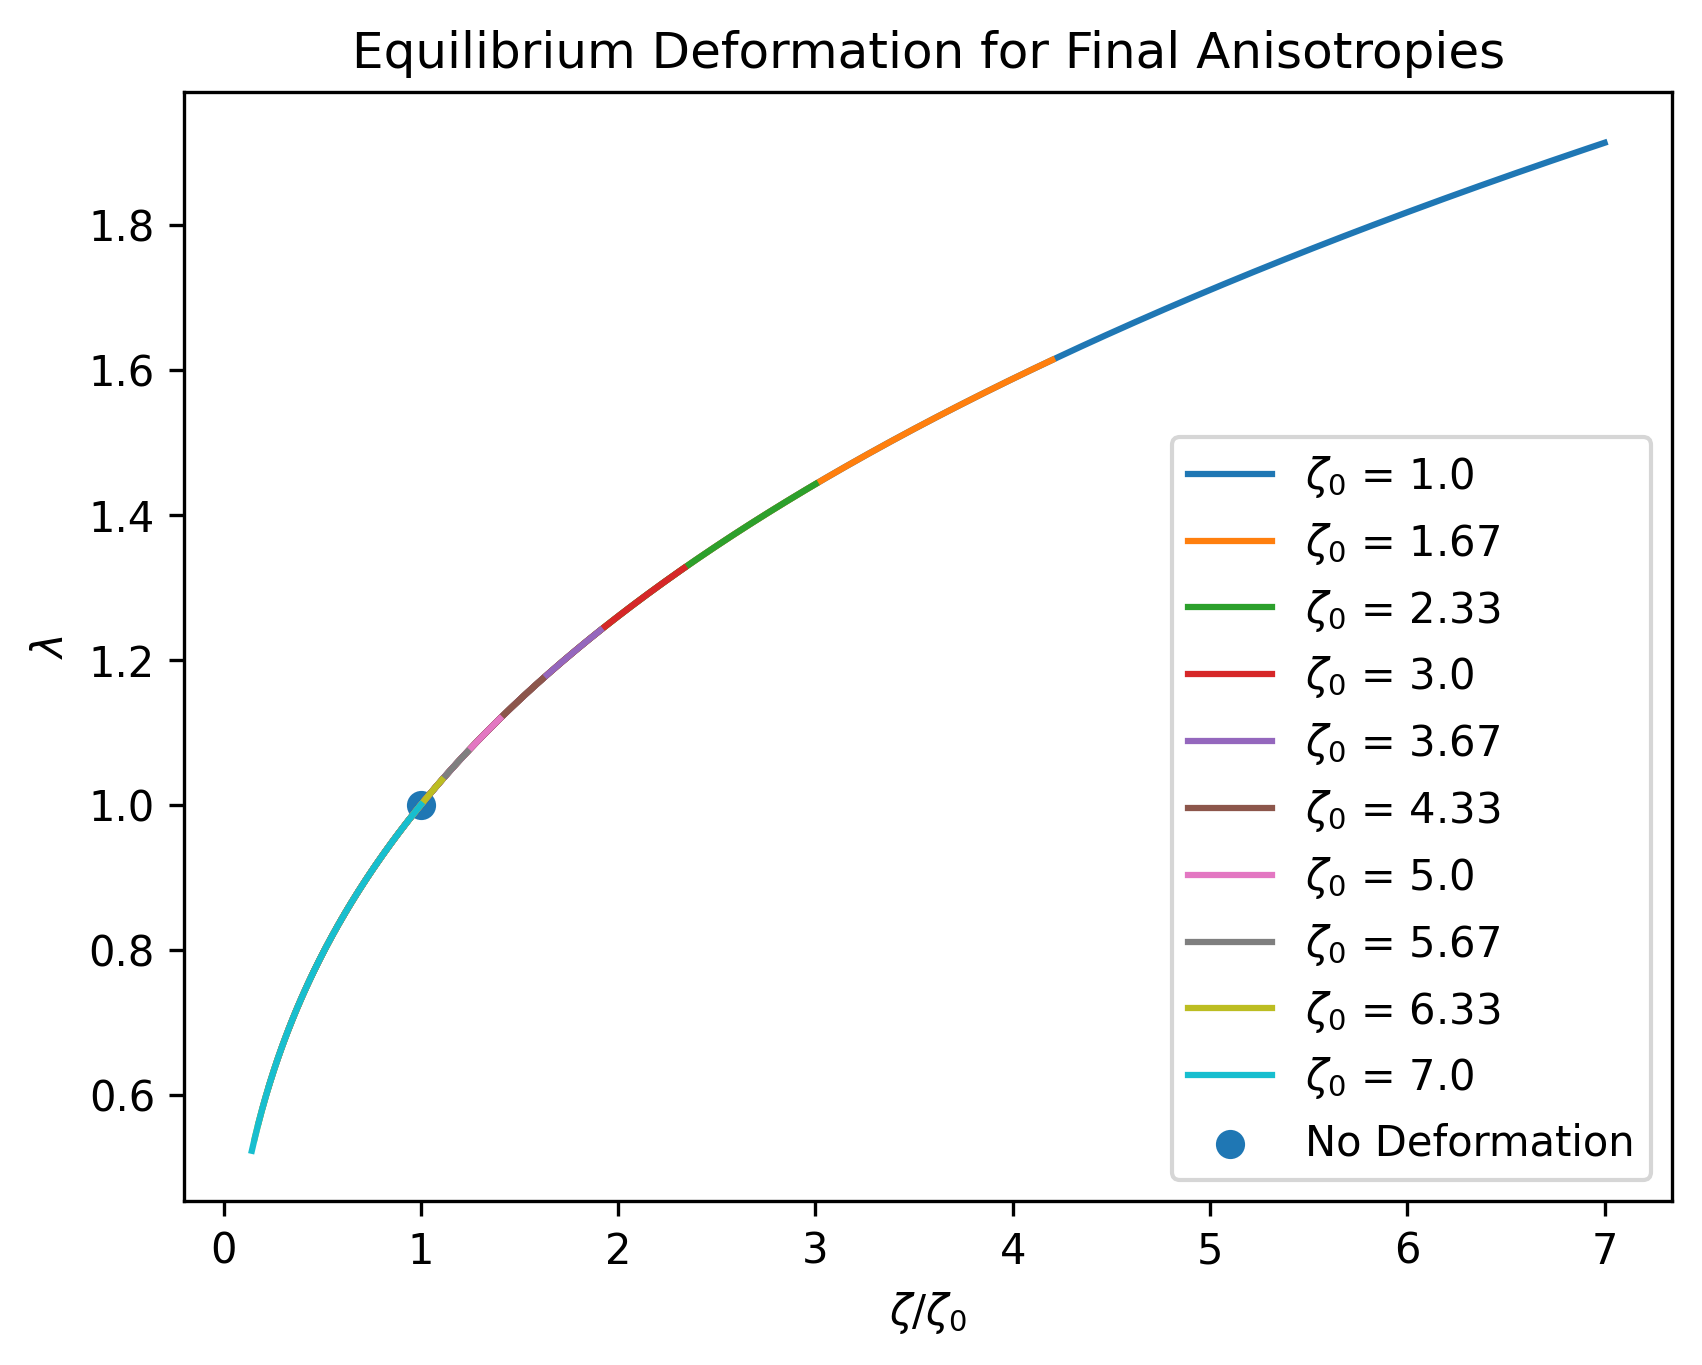

In [109]:
# Take a series of initial anisotropic parameters zeta

n = 10
zeta_0_a = np.linspace(1,7,n)

zeta_a = np.linspace(1,7, 200)

plt.figure(dpi=300)
for i in range(n):
    zeta_0_i = zeta_0_a[i]
    fun = sp.lambdify([zeta], sol_lam[0].evalf(subs={zeta_0:zeta_0_i}), modules='numpy')
    lambdas = fun(zeta_a)
    plt.plot(zeta_a/zeta_0_i, lambdas, label=r"$\zeta_0$ = " + str(round(zeta_0_i, 2)))

plt.scatter([1], [1], label='No Deformation')
plt.xlabel(r'$\zeta / \zeta_0$')
plt.ylabel(r'$\lambda$')
plt.title("Equilibrium Deformation for Final Anisotropies")
plt.legend()
plt.show()


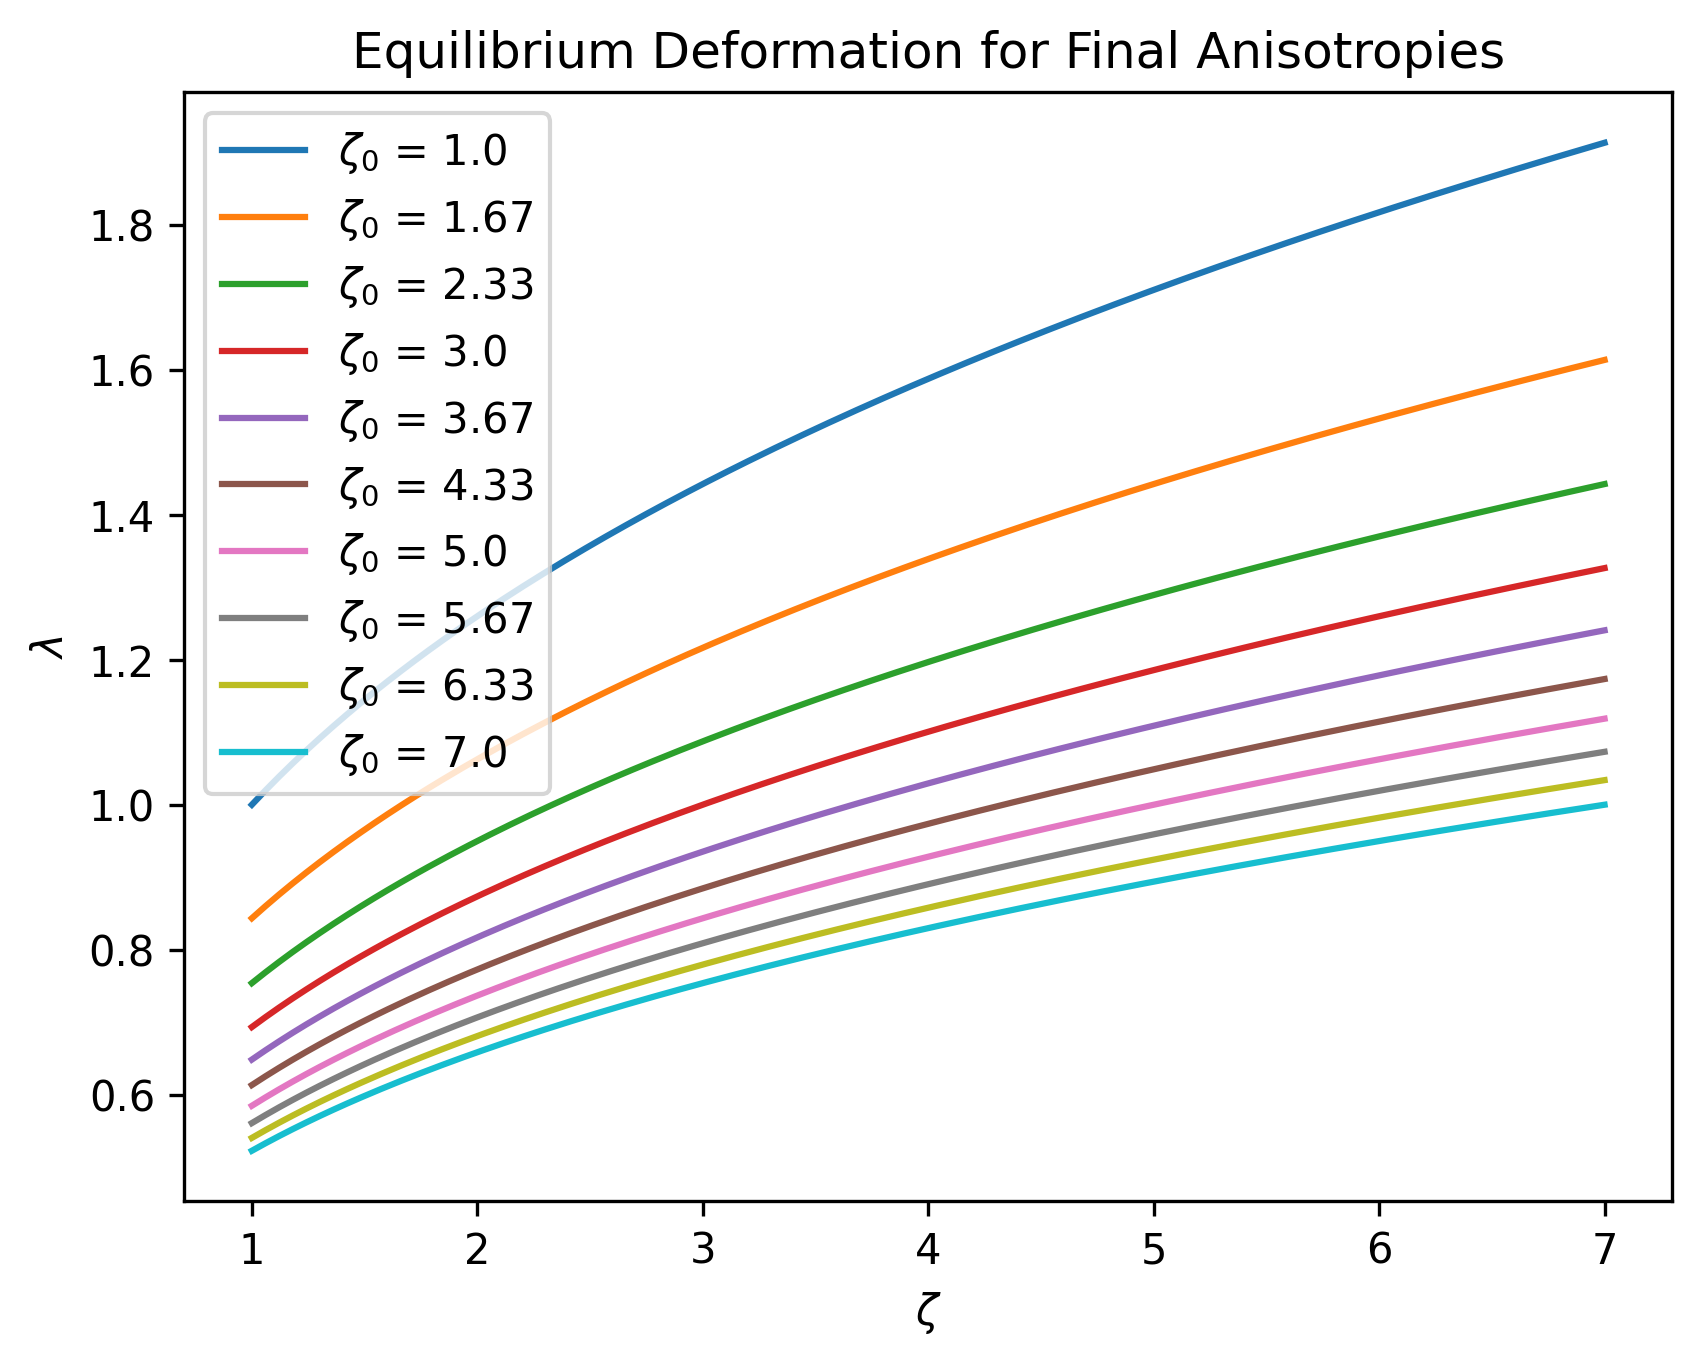

In [110]:
plt.figure(dpi=300)
for i in range(n):
    zeta_0_i = zeta_0_a[i]
    fun = sp.lambdify([zeta], sol_lam[0].evalf(subs={zeta_0:zeta_0_i}), modules='numpy')
    lambdas = fun(zeta_a)
    plt.plot(zeta_a, lambdas, label=r"$\zeta_0$ = " + str(round(zeta_0_i, 2)))

plt.xlabel(r'$\zeta$')
plt.ylabel(r'$\lambda$')
plt.title("Equilibrium Deformation for Final Anisotropies")
plt.legend()
plt.show()

So what I can get from this is that theres a relationship between the ratios of anisotropy parameter, that is, how the LCE deformed, with the enlogation parameter. This is somewhat trivial, as we would expect the changes in the deformation taking place with the anisotrpy parameter, which in a way describe how is our system arranged.

In terms of the whole model, and the results we would expect from our hydration model, is that:
- Theres anisotropic expansion, anisotropic enlongation (not as a result of a fixed volume but rather as a result of the hydration, and therefore theres more expansion in one side than the other). This means that we would expect to find the Young Moduli to be different one of another, that is:

$$
\frac{E_r}{E_z} \neq 1
$$

- The volume doesnt keeps fixed. When hydrated, the fibers become bigger. This is in a way logical as theres an input of water molecules (which obviosuly occupy space). As there's no shear expected, one can write the deformation tensor, in principle, as:

$$
\bold{\Lambda} = \text{diag}(\lambda_x,\lambda_y,\lambda_z) = \text{diag}(\lambda_r, \lambda_r, \lambda_z)
$$

Given that if you rotate the system, in principle (**to see**) there shouldn't be a distinction.

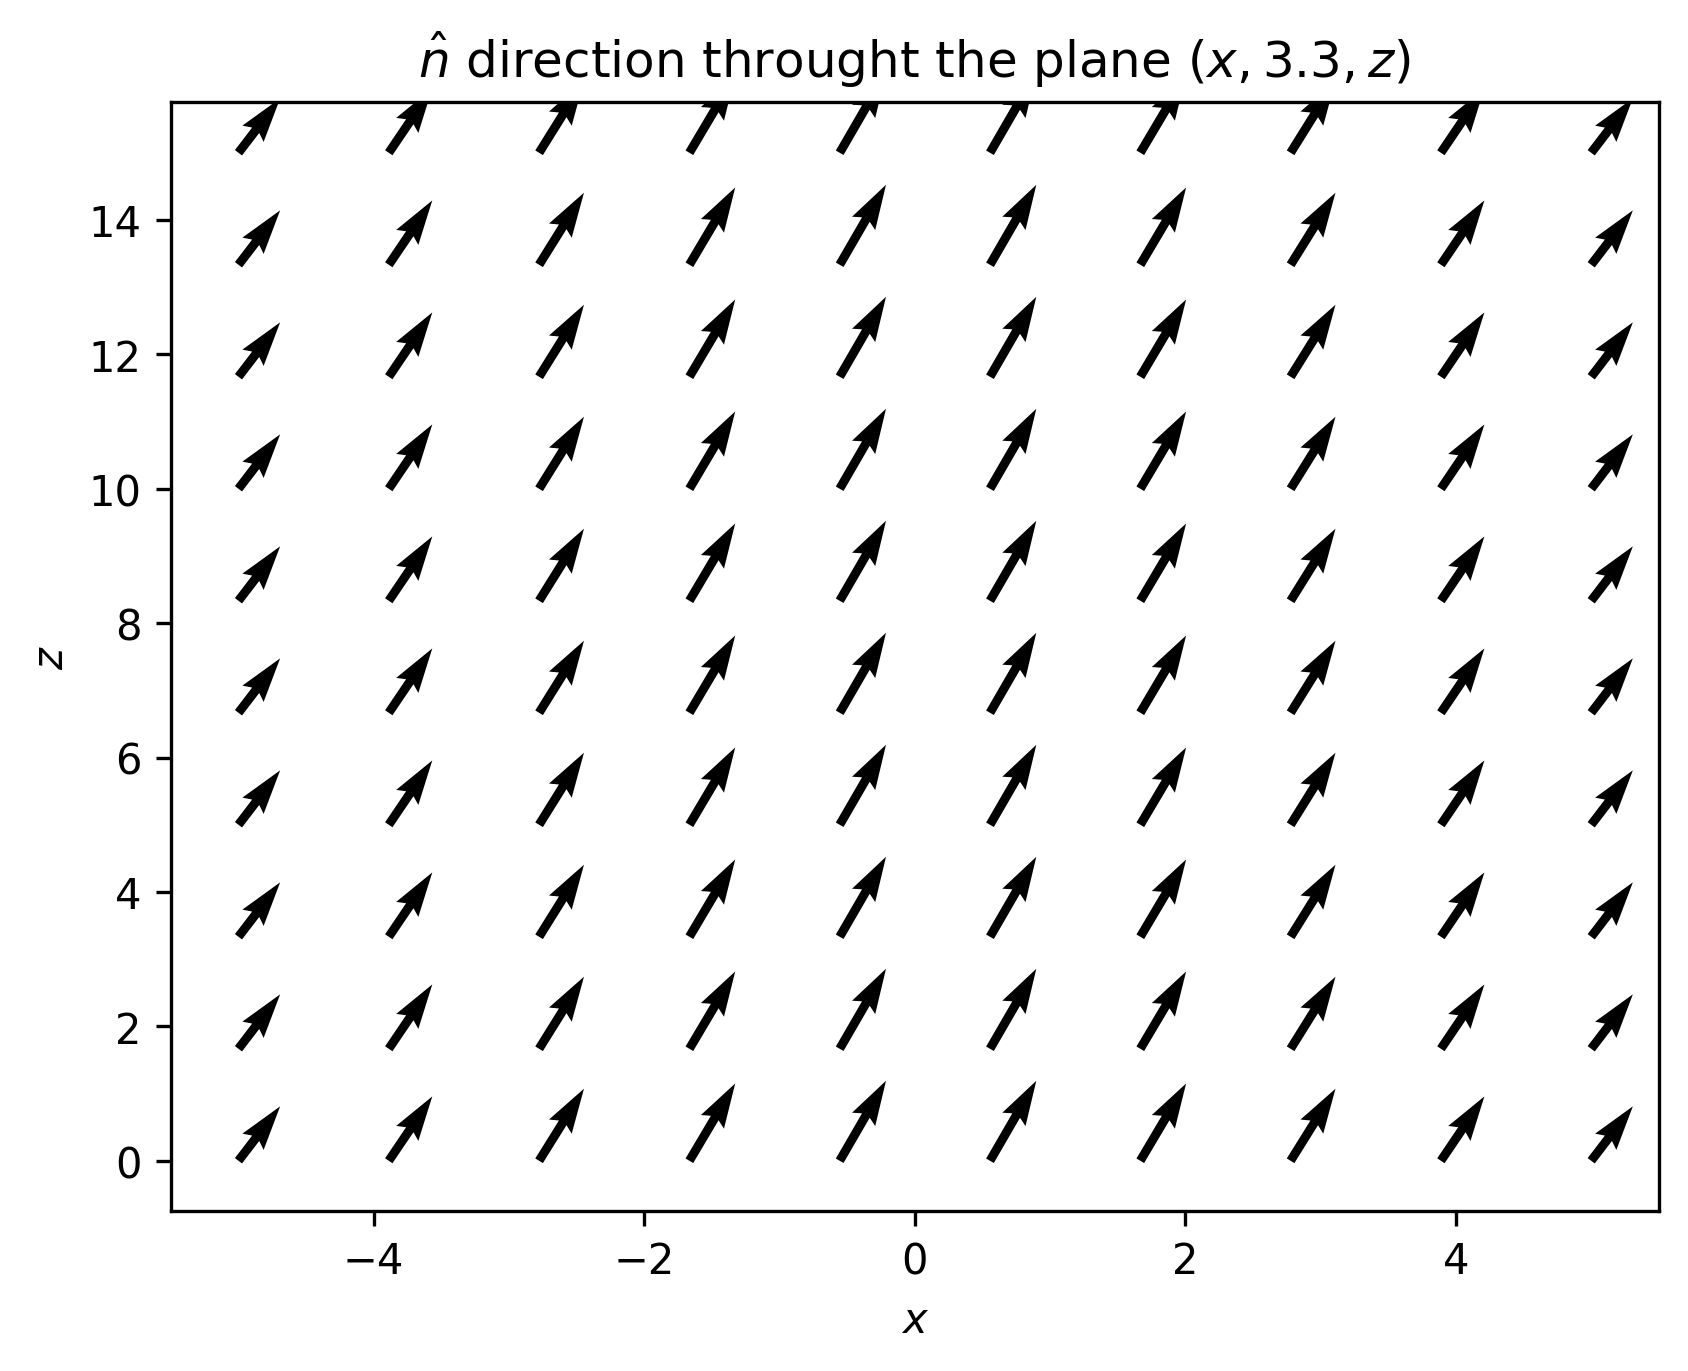

In [114]:
# Lets explore the symmetry
N = 10
xlims = 5
x = np.linspace(-xlims, xlims, N)
y = xlims*2/3
z = np.linspace(0, 15, N)

X,Z = np.meshgrid(x, z)

T = np.arctan2(y,X)

# twist = np.deg2rad(1)*np.sqrt(X**2 + y**2)
twist = np.deg2rad(90/(2*xlims))*np.sqrt(X**2 + y**2)

nx = np.sin(twist)*np.sin(T)
nz = np.cos(twist)

plt.figure(dpi=300)
plt.quiver(X, Z, nx, nz)
plt.title(r"$\hat{n}$" + " direction throught the plane" + fr" $(x,{round(y, 1)},z)$")
plt.xlabel(r"$x$")
plt.ylabel(r"$z$")
plt.show()

This linear twist, as long as it is maintained in the regime $\psi \in [0, \pi]$, then it correctly models a good twist. The geometry should look something like this:

<img src="twist_exp.png" alt="Example for the director field view of the mesogens of a LC with doulbe twist" width="300"/>

As it can be seen, the radius greatly determines the twist angle, in which for the case of the center, there is no twist as such.

Lets make it 3D.

In [112]:
first = -20
last = 20
n = 4

x, y, z = np.meshgrid(np.linspace(first, last, n),
                      np.linspace(first, last, n),
                      np.linspace(0, last, n))

theta =  np.arctan2(y, x)

twist = np.deg2rad(90/(2*last))*np.sqrt(x**2 + y**2)

theta_x = -np.sin(theta)
theta_y = np.cos(theta)

theta_x_tilt = -np.sin(twist)*theta_x
theta_y_tilt = np.cos(twist)*theta_y

z_tilt = np.cos(twist)

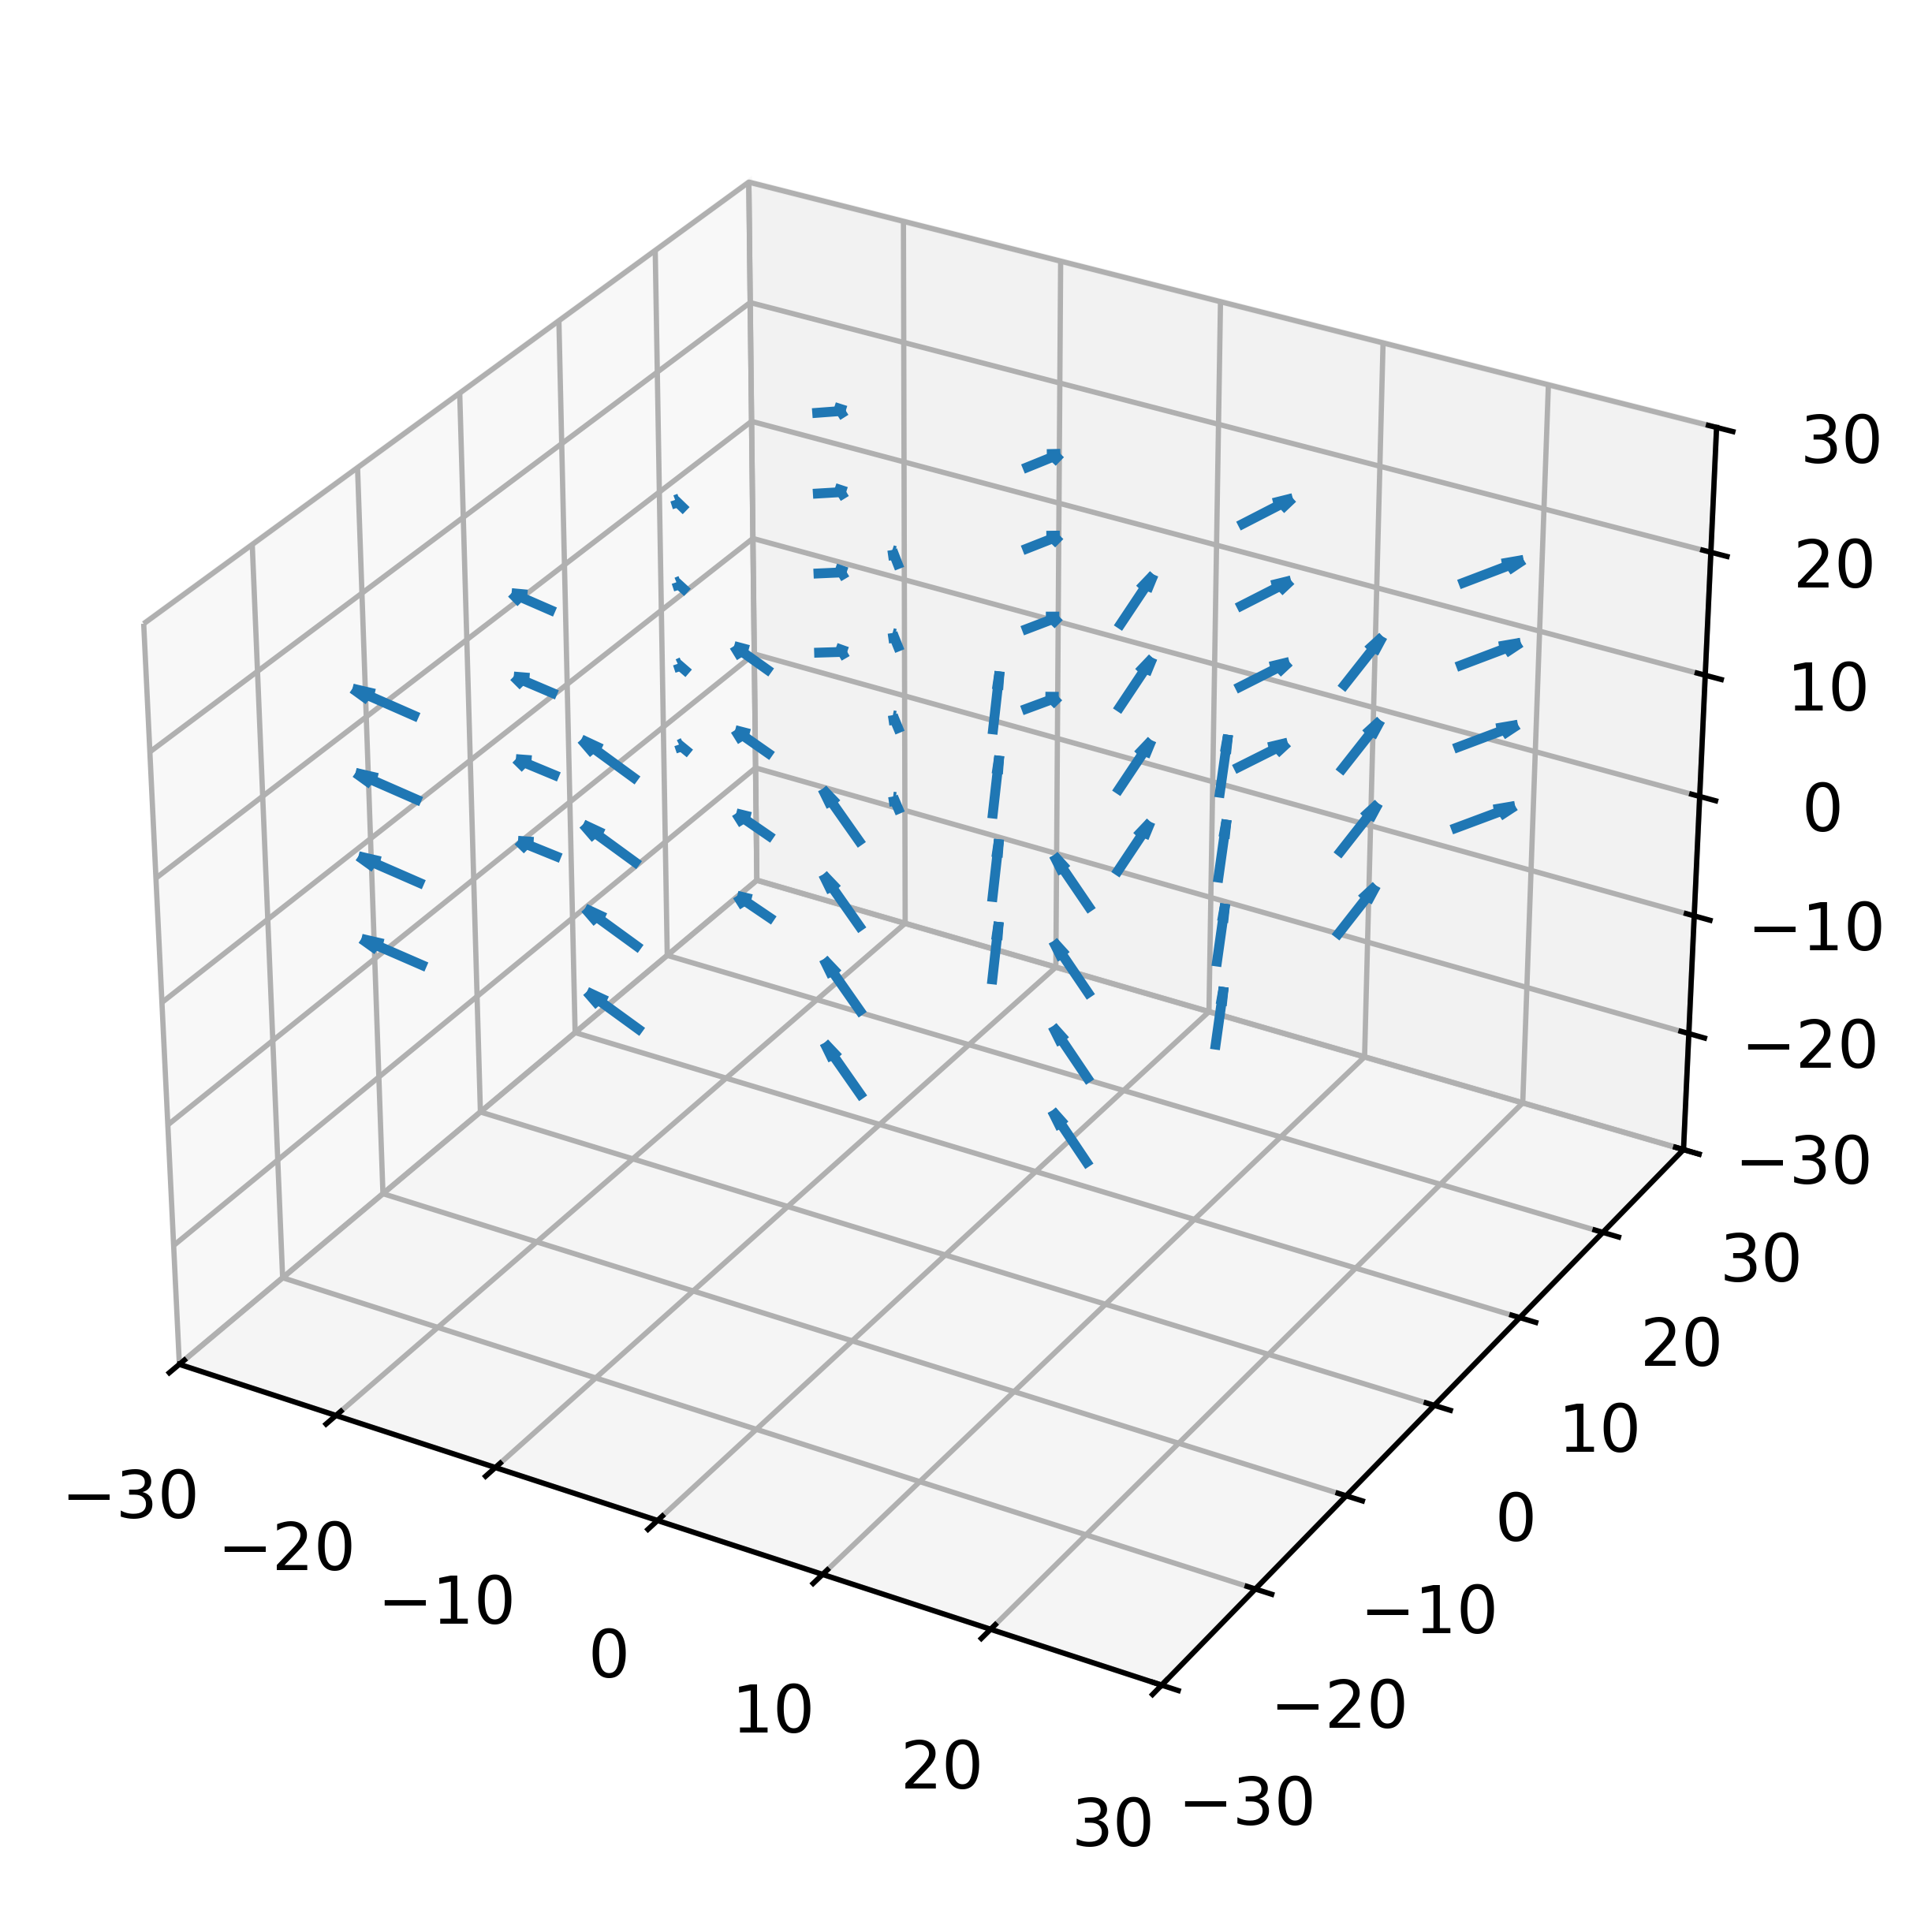

In [113]:
# Show the 3D
ax = plt.figure(dpi=600).add_subplot(projection='3d')
ax.quiver(x, y, z, theta_x_tilt, theta_y_tilt, z_tilt, length=4, normalize=1)
ax.axes.set_xlim3d(left=first*1.5, right=last*1.5) 
ax.axes.set_ylim3d(bottom=first*1.5, top=last*1.5) 
ax.axes.set_zlim3d(bottom=first*1.5, top=last*1.5) 
plt.show()